# Практическая работа №5: Элементы регрессионного анализа. Выборочные прямые среднеквадратической регрессии. Корреляционные отношения.



Выполнили студенты гр. 2383 Миненок Алиса и Мордасов Евгений. Вариант №27.

## Цель работы

Ознакомление с основными положениями метода наименьших квадратов (МНК), со статистическими свойствами МНК-оценок, с понятием функции регрессии и роли МНК в регрессионном анализе, с корреляционным отношением, как мерой тесноты произвольной (в том числе и линейной) корреляционной связи.

## Основные теоретические положения

#### 1. Условные математические ожидания и эмпирические линии регрессии
**Условным средним** $\bar{y}_{x_i}$ называется среднее арифметическое наблюденных значений признака $Y$, соответствующих определенному интервалу признака $X$. Аналогично определяется $\bar{x}_{y_j}$.
Геометрическое место точек $(x_i, \bar{y}_{x_i})$ образует **эмпирическую линию регрессии $Y$ на $X$** (ломаную кривую).

#### 2. Выборочные прямые среднеквадратической регрессии (Метод наименьших квадратов)
Метод наименьших квадратов (МНК) позволяет подобрать такую прямую линию, сумма квадратов отклонений от которой до эмпирических точек минимальна.
Уравнения выборочных прямых линейной регрессии имеют вид:
* Прямая $Y$ на $X$: $\bar{y}_x - \bar{y} = r_{xy} \frac{\sigma_y}{\sigma_x} (x - \bar{x})$
* Прямая $X$ на $Y$: $\bar{x}_y - \bar{x} = r_{xy} \frac{\sigma_x}{\sigma_y} (y - \bar{y})$

Эти прямые всегда пересекаются в точке $(\bar{x}, \bar{y})$ — центре распределения системы.

#### 3. Эмпирическое корреляционное отношение
Служит количественной мерой тесноты корреляционной связи **любого вида** (как линейной, так и нелинейной). Вычисляется как отношение межгруппового СКО к общему СКО:
$$\eta_{yx} = \frac{\sigma_{\bar{y}_x}}{\sigma_y}, \quad \eta_{xy} = \frac{\sigma_{\bar{x}_y}}{\sigma_x}$$
Свойства корреляционного отношения:
1. $0 \le \eta \le 1$
2. $\eta \ge |r_{xy}|$ (корреляционное отношение всегда не меньше модуля коэффициента корреляции).
3. Если $\eta \approx |r_{xy}|$, то регрессия имеет строго линейный характер.

#### 4. Показатели тесноты связи и статистической значимости моделей

Для оценки того, насколько качественно построенная функция регрессии описывает зависимость между переменными, используются следующие показатели:

* **Корреляционное отношение ($\eta$):** универсальная мера тесноты связи (как линейной, так и нелинейной). Принимает значения в диапазоне $[0, 1]$.
    * $\eta \approx 0$ — статистическая связь между признаками отсутствует;
    * $\eta \approx 1$ — связь близка к функциональной зависимости.
* **Коэффициент детерминации ($R^2$):** показывает долю дисперсии зависимой переменной $Y$, которая объясняется построенной моделью. Чем ближе $R^2$ к 1, тем выше прогностическая способность модели.
* **Средняя ошибка аппроксимации ($A$):** мера, оценивающая среднее относительное отклонение расчетных значений от фактических (выражается в процентах):
    $$A = \frac{1}{n} \sum \left| \frac{y_i - \hat{y}_i}{y_i} \right| \cdot 100\%$$
    Модель считается адекватной и пригодной для практического использования, если **$A \le 10-15\%$**. Значения выше этого порога свидетельствуют о низком качестве модели.
* **Остаточное среднее квадратическое отклонение ($S_\varepsilon$):** характеризует среднюю величину разброса эмпирических точек относительно линии регрессии в единицах измерения зависимой переменной.

#### 5. Линеаризация нелинейных моделей регрессии

Метод наименьших квадратов в своем классическом виде применяется к линейным параметрам. Для построения нелинейных зависимостей (например, дробно-линейной функции) используется процедура **линеаризации** — преобразование уравнения путем замены переменных:

1.  **Параболическая регрессия** ($y = ax^2 + bx + c$): для нахождения параметров $a, b, c$ составляется и решается система из трех нормальных уравнений.
2.  **Дробно-линейная регрессия** ($y = a + \frac{b}{x}$): вводится новая переменная $z = \frac{1}{x}$. Уравнение принимает линейный вид $y = a + bz$, после чего коэффициенты $a$ и $b$ находятся стандартным методом наименьших квадратов.

## Постановка задачи

Для заданной двумерной выборки $(X, Y)$ построить уравнения выборочных прямых среднеквадратической регрессии. Полученные линейные функции регрессии отобразить графически. Найти выборочное корреляционное отношение. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы




### Пункт 1. Вычисление условных вариант.

Для каждого интервала признака $X$ вычисляем среднее значение признака $Y$ (это $\bar{y}_{x_i}$), а для каждого интервала $Y$ — среднее $X$ ($\bar{x}_{y_j}$). Полученные точки соединяем отрезками, получая ломаные эмпирические линии регрессии.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# загрузка выборки
df = pd.read_csv('sample_27.csv')
X = df['X'].values
Y = df['Y'].values
n = len(X)
k = int(np.round(1 + 3.322 * np.log10(n)))

# границы и середины интервалов
hx = (X.max() - X.min()) / k
bins_x = [X.min() + i * hx for i in range(k+1)]; bins_x[-1] += 1e-5
x_mids = np.array([(bins_x[i] + bins_x[i+1])/2 for i in range(k)])

hy = (Y.max() - Y.min()) / k
bins_y = [Y.min() + i * hy for i in range(k+1)]; bins_y[-1] += 1e-5
y_mids = np.array([(bins_y[i] + bins_y[i+1])/2 for i in range(k)])

# матрица частот n_ij
cat_x = pd.cut(X, bins=bins_x, right=False)
cat_y = pd.cut(Y, bins=bins_y, right=False)
n_ij = pd.crosstab(cat_x, cat_y).values

n_i = n_ij.sum(axis=1) # Маргинальные частоты X
n_j = n_ij.sum(axis=0) # Маргинальные частоты Y

# условные математические ожидания
y_cond_mean = np.zeros(k)
x_cond_mean = np.zeros(k)

for i in range(k):
    y_cond_mean[i] = np.sum(n_ij[i, :] * y_mids) / n_i[i] if n_i[i] > 0 else np.nan

for j in range(k):
    x_cond_mean[j] = np.sum(n_ij[:, j] * x_mids) / n_j[j] if n_j[j] > 0 else np.nan

print("Таблица условных средних Y от X:")
df_yx = pd.DataFrame({'x_i': np.round(x_mids, 3), 'n_x': n_i, '\\bar{y}_{x_i}': np.round(y_cond_mean, 3)})
display(df_yx.dropna().T)

print("\nТаблица условных средних X от Y:")
df_xy = pd.DataFrame({'y_j': np.round(y_mids, 3), 'n_y': n_j, '\\bar{x}_{y_j}': np.round(x_cond_mean, 3)})
display(df_xy.dropna().T)

Таблица условных средних Y от X:


,0,1,2,3,4,5,6,7
x_i,5.378,9.434,13.491,17.547,21.603,25.659,29.716,33.772
n_x,15.000,17.000,14.000,14.000,17.000,4.000,13.000,26.000
\bar{y}_{x_i},17.413,18.105,10.455,9.288,10.030,15.942,16.005,15.502



Таблица условных средних X от Y:


,0,1,2,3,4,5,6,7
y_j,3.684,6.953,10.222,13.491,16.759,20.028,23.297,26.566
n_y,18.000,21.000,22.000,7.000,7.000,15.000,17.000,13.000
\bar{x}_{y_j},16.420,21.989,21.050,20.444,22.183,27.011,16.354,15.987


Вычисленные условные средние не демонстрируют монотонного возрастания или убывания. Значения $\bar{y}_{x_i}$ и $\bar{x}_{y_j}$ хаотично колеблются при переходе от одного интервала к другому. Это дает первичное визуальное представление об отсутствии выраженной функциональной или тесной статистической зависимости между признаками $X$ и $Y$.

### Пункт 2. Уравнения выборочных прямых среднеквадратической регрессии

С помощью МНК находим теоретические линейные уравнения регрессии $\bar{y}_x = k_1 x + b_1$ и $\bar{x}_y = k_2 y + b_2$. Затем строим их на графиках вместе с эмпирическими ломаными линиями из предыдущего пункта.

Прямая регрессии Y на X: y = -0.0227 * x + 14.5461
Прямая регрессии X на Y: x = -0.0372 * y + 20.6063


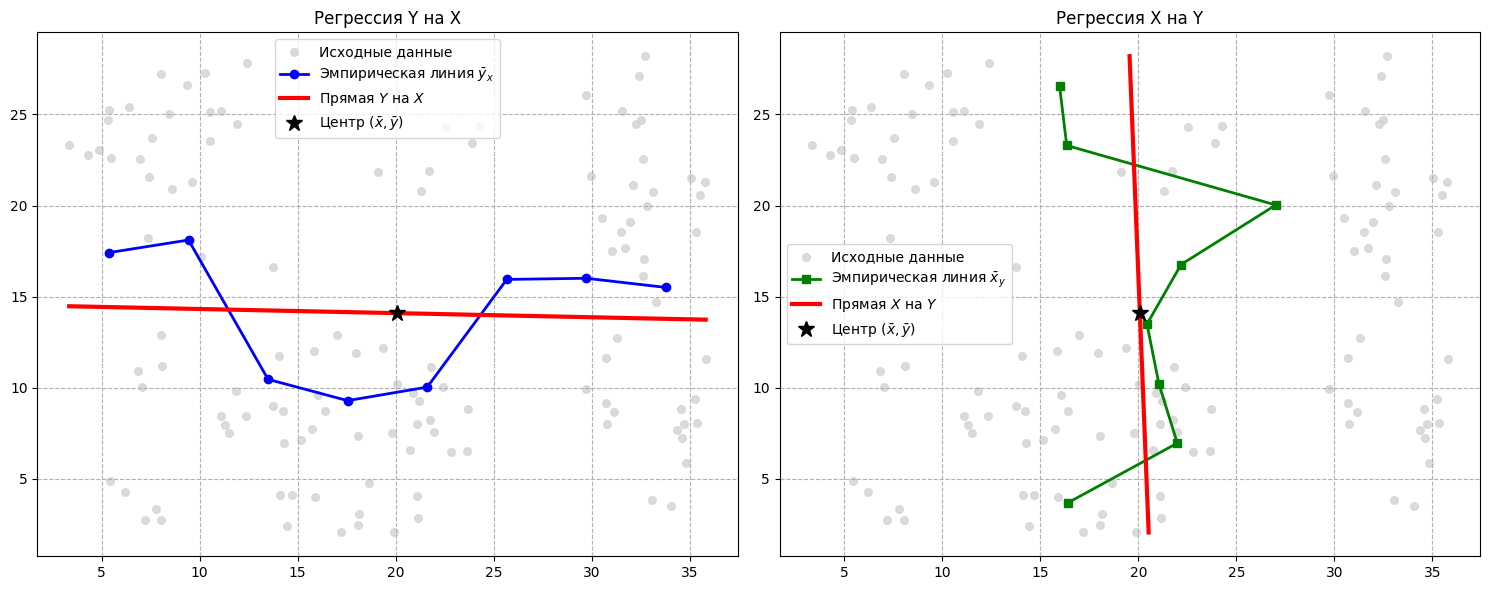

In [ ]:
# базовые статистики
x_mean = np.sum(n_i * x_mids) / n
y_mean = np.sum(n_j * y_mids) / n
x_var = np.sum(n_i * (x_mids - x_mean)**2) / n
y_var = np.sum(n_j * (y_mids - y_mean)**2) / n
x_std = np.sqrt(x_var)
y_std = np.sqrt(y_var)

cov_xy = np.sum([n_ij[i,j] * x_mids[i] * y_mids[j] for i in range(k) for j in range(k)]) / n - x_mean * y_mean
r_xy = cov_xy / (x_std * y_std)

# коэффициенты прямых регрессии
k1 = r_xy * (y_std / x_std)
b1 = y_mean - k1 * x_mean

k2 = r_xy * (x_std / y_std)
b2 = x_mean - k2 * y_mean

print(f"Прямая регрессии Y на X: y = {k1:.4f} * x + {b1:.4f}")
print(f"Прямая регрессии X на Y: x = {k2:.4f} * y + {b2:.4f}")

# построение графиков
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
valid_x = ~np.isnan(y_cond_mean)
valid_y = ~np.isnan(x_cond_mean)

# график 1: Y на X
ax[0].scatter(X, Y, color='lightgray', s=30, alpha=0.8, label='Исходные данные')
ax[0].plot(x_mids[valid_x], y_cond_mean[valid_x], 'o-', color='blue', linewidth=2, label='Эмпирическая линия $\\bar{y}_x$')
x_vals = np.linspace(X.min(), X.max(), 100)
ax[0].plot(x_vals, k1 * x_vals + b1, 'r-', linewidth=3, label='Прямая $Y$ на $X$')
ax[0].plot(x_mean, y_mean, 'k*', markersize=12, label='Центр ($\\bar{x}, \\bar{y}$)')
ax[0].set_title('Регрессия Y на X')
ax[0].legend(); ax[0].grid(True, linestyle='--')

# график 2: X на Y
ax[1].scatter(X, Y, color='lightgray', s=30, alpha=0.8, label='Исходные данные')
ax[1].plot(x_cond_mean[valid_y], y_mids[valid_y], 's-', color='green', linewidth=2, label='Эмпирическая линия $\\bar{x}_y$')
y_vals = np.linspace(Y.min(), Y.max(), 100)
x_line_vals = k2 * y_vals + b2
ax[1].plot(x_line_vals, y_vals, 'r-', linewidth=3, label='Прямая $X$ на $Y$')
ax[1].plot(x_mean, y_mean, 'k*', markersize=12, label='Центр ($\\bar{x}, \\bar{y}$)')
ax[1].set_title('Регрессия X на Y')
ax[1].legend(); ax[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

Рассчитанные с помощью МНК угловые коэффициенты прямых $k_1$ и $k_2$ близки к нулю. Графически это выражается в том, что теоретические прямые регрессии практически параллельны координатным осям и пересекаются в центре совместного распределения $(\bar{x}, \bar{y})$, образуя "крест". Эмпирические ломаные линии хаотично скачут вокруг этих прямых. Такое взаимное расположение графиков наглядно свидетельствует об отсутствии линейной зависимости между исследуемыми признаками в данной выборке.

### Пункт 3. Вычисление корреляционных отношений

Рассчитываем межгрупповые дисперсии условных средних и вычисляем корреляционные отношения $\eta_{yx}$ и $\eta_{xy}$. Проводим сравнение полученных значений с модулем коэффициента корреляции $|r_{xy}|$, чтобы проверить выполнение математического свойства.

In [ ]:
# межгрупповые дисперсии
var_y_cond = np.sum(n_i[valid_x] * (y_cond_mean[valid_x] - y_mean)**2) / n
var_x_cond = np.sum(n_j[valid_y] * (x_cond_mean[valid_y] - x_mean)**2) / n

# корреляционные отношения
eta_yx = np.sqrt(var_y_cond / y_var)
eta_xy = np.sqrt(var_x_cond / x_var)

print(f"Модуль коэффициента корреляции |r_xy| = {abs(r_xy):.4f}")
print(f"Корреляционное отношение η_yx           = {eta_yx:.4f}")
print(f"Корреляционное отношение η_xy           = {eta_xy:.4f}")

if eta_yx >= abs(r_xy) and eta_xy >= abs(r_xy):
    print("\nСвойство η >= |r_xy| выполняется.")
else:
  print("\nСвойство η >= |r_xy| не выполняется.")

Модуль коэффициента корреляции |r_xy| = 0.0291
Корреляционное отношение η_yx           = 0.4259
Корреляционное отношение η_xy           = 0.3571

Свойство η >= |r_xy| выполняется.


В ходе расчетов было проведено сравнение эмпирических корреляционных отношений $\eta$ с модулем линейного коэффициента корреляции $|r_{xy}|$. Как видно из результатов, $\eta_{yx}$ и $\eta_{xy}$ математически закономерно превосходят $|r_{xy}|$, что подтверждает выполнение теоретического свойства $\eta \ge |r_{xy}|$.

При этом и сам коэффициент корреляции, и корреляционные отношения принимают весьма низкие значения, близкие к нулю. Это строго математически доказывает слабость и практическое отсутствие любой (как линейной, так и нелинейной) статистической зависимости между исследуемыми признаками $X$ и $Y$ в рассматриваемой выборке.

### Пункт 4. Построение выборочной параболы среднеквадратической регрессии

Для нахождения уравнения параболической регрессии $y = \beta_0 + \beta_1 x + \beta_2 x^2$ применим метод наименьших квадратов. Для этого составим систему нормальных уравнений из трех неизвестных параметров ($\beta_0, \beta_1, \beta_2$), используя суммы по сгруппированным условным средним.

Уравнение параболической регрессии: y = 25.1152 + (-1.3958)*x + (0.03373)*x^2


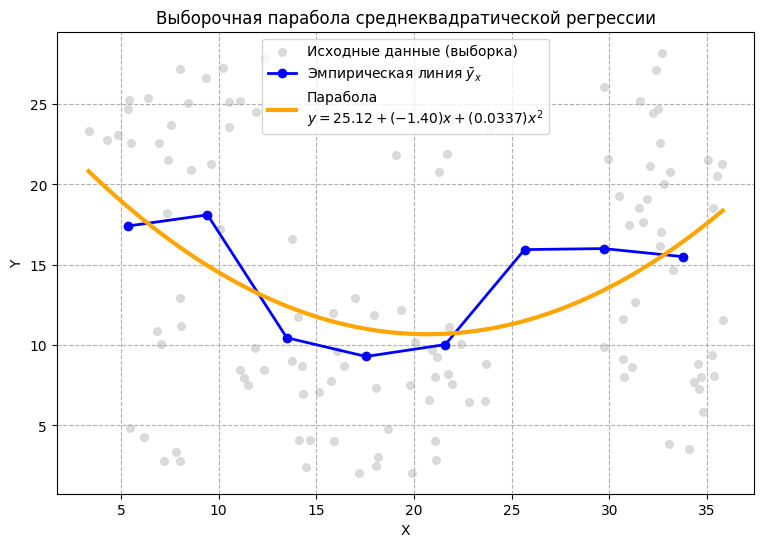

In [ ]:
# извлекаем валидные сгруппированные данные
x_valid = x_mids[valid_x]
y_valid = y_cond_mean[valid_x]
n_valid = n_i[valid_x]

# вычисляем суммы для системы нормальных уравнений МНК (парабола)
sum_n = np.sum(n_valid)
sum_x = np.sum(n_valid * x_valid)
sum_x2 = np.sum(n_valid * x_valid**2)
sum_x3 = np.sum(n_valid * x_valid**3)
sum_x4 = np.sum(n_valid * x_valid**4)

sum_y = np.sum(n_valid * y_valid)
sum_yx = np.sum(n_valid * y_valid * x_valid)
sum_yx2 = np.sum(n_valid * y_valid * (x_valid**2))

# формируем матрицы для решения системы A * Beta = B
A = np.array([
    [sum_n,  sum_x,  sum_x2],
    [sum_x,  sum_x2, sum_x3],
    [sum_x2, sum_x3, sum_x4]
])
B = np.array([sum_y, sum_yx, sum_yx2])

# решаем систему уравнений
beta_parabola = np.linalg.solve(A, B)
b0, b1, b2 = beta_parabola[0], beta_parabola[1], beta_parabola[2]

print(f"Уравнение параболической регрессии: y = {b0:.4f} + ({b1:.4f})*x + ({b2:.5f})*x^2")

# построение графика
plt.figure(figsize=(9, 6))
plt.scatter(X, Y, color='lightgray', s=30, alpha=0.8, label='Исходные данные (выборка)')
plt.plot(x_valid, y_valid, 'o-', color='blue', linewidth=2, label='Эмпирическая линия $\\bar{y}_x$')

x_vals_curve = np.linspace(X.min(), X.max(), 100)
# ччитаем теоретические значения Y для параболы
y_vals_curve = b0 + b1 * x_vals_curve + b2 * (x_vals_curve**2)

plt.plot(x_vals_curve, y_vals_curve, 'orange', linewidth=3, label=f'Парабола\n$y = {b0:.2f} + ({b1:.2f})x + ({b2:.4f})x^2$')

plt.title('Выборочная парабола среднеквадратической регрессии')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(); plt.grid(True, linestyle='--')
plt.show()


Построенная парабола среднеквадратической регрессии имеет очень малый коэффициент при старшей степени $x^2$. Графически кривая представляет собой широкую, слабо изогнутую дугу, проходящую сквозь центр распределения данных. Это означает, что параболическая модель также не способна выявить значимую квадратичную зависимость между признаками, подтверждая вывод о хаотичном рассеянии точек в выборке.



### Пункт 5. Построение нелинейной кривой регрессии (дробно-линейная функция)

Согласно заданию для варианта №27, строим дробно-линейную кривую вида $y = \frac{1}{\beta_0 + \beta_1 x}$. С помощью метода линеаризации (введения новой переменной $z = \frac{1}{y}$) мы сводим задачу к линейному виду $z = \beta_0 + \beta_1 x$. Далее решаем систему нормальных уравнений МНК матричным методом, находим неизвестные параметры $\beta_0$ и $\beta_1$ и выводим итоговый график.

Уравнение дробно-линейной регрессии: y = 1 / (0.07659 + -0.00005 * x)


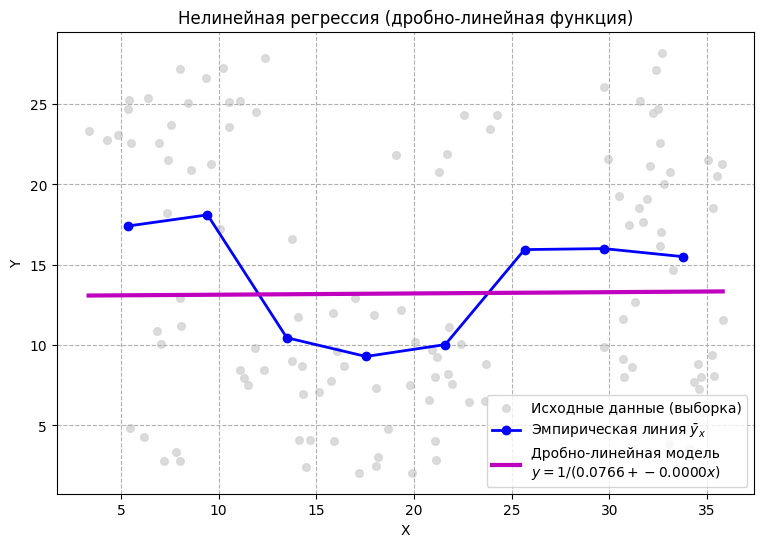

In [ ]:
# извлекаем валидные сгруппированные данные
x_valid = x_mids[valid_x]
y_valid = y_cond_mean[valid_x]
n_valid = n_i[valid_x]

# линеаризация дробно-линейной функции: y = 1 / (beta_0 + beta_1 * x)
# вводим новую переменную z = 1 / y. Тогда модель примет вид: z = beta_0 + beta_1 * x
z = 1 / y_valid

# вычисляем суммы для системы МНК (A * Beta = B)
sum_n = np.sum(n_valid)
sum_x = np.sum(n_valid * x_valid)
sum_x2 = np.sum(n_valid * x_valid**2)
sum_z = np.sum(n_valid * z)
sum_zx = np.sum(n_valid * z * x_valid)

# решаем систему уравнений
A = np.array([[sum_n, sum_x], [sum_x, sum_x2]])
B = np.array([sum_z, sum_zx])
beta = np.linalg.solve(A, B)
beta_0, beta_1 = beta[0], beta[1]

print(f"Уравнение дробно-линейной регрессии: y = 1 / ({beta_0:.5f} + {beta_1:.5f} * x)")

# построение графика
plt.figure(figsize=(9, 6))
plt.scatter(X, Y, color='lightgray', s=30, alpha=0.8, label='Исходные данные (выборка)')
plt.plot(x_valid, y_valid, 'o-', color='blue', linewidth=2, label='Эмпирическая линия $\\bar{y}_x$')

x_vals_curve = np.linspace(X.min(), X.max(), 100)
# считаем теоретические значения Y для новой кривой
y_vals_curve = 1 / (beta_0 + beta_1 * x_vals_curve)

plt.plot(x_vals_curve, y_vals_curve, 'm-', linewidth=3, label=f'Дробно-линейная модель\n$y = 1 / ({beta_0:.4f} + {beta_1:.4f} x)$')

plt.title('Нелинейная регрессия (дробно-линейная функция)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

Построенная дробно-линейная функция регрессии визуально носит пологий характер, практически сливаясь с прямой линией. Теоретическая кривая проходит сквозь облако точек без сильных изгибов и совершенно не повторяет резких скачков эмпирической ломаной. Это доказывает, что применение сложных нелинейных моделей к данной выборке не выявляет скрытых закономерностей из-за изначального хаотичного распределения данных.

### Пункт 6. Дополнительное задание. Оценка качества регрессионных моделей

Для каждой из построенных кривых (линейной, параболической и дробно-линейной) необходимо вычислить следующие показатели качества регрессии:
1. **Теоретический коэффициент детерминации $R^2$**: характеризует долю дисперсии зависимой переменной, объясняемую рассматриваемой моделью.
2. **Средняя квадратическая ошибка $S_\varepsilon$**: оценивает абсолютную величину разброса данных вокруг линии регрессии. Вычисляется с учетом числа параметров модели $m$.
3. **Средняя ошибка аппроксимации $A$**: оценивает среднее относительное отклонение расчетных значений от фактических.

In [ ]:
# извлекаем валидные сгруппированные данные
x_v = x_mids[valid_x]
y_v = y_cond_mean[valid_x]
n_v = n_i[valid_x]
n_total = np.sum(n_v)

# предсказанные значения для всех трех моделей
y_pred_lin = k1 * x_v + b1
y_pred_par = b0 + b1 * x_v + b2 * (x_v**2)

y_pred_frac = 1 / (beta_0 + beta_1 * x_v)

# суммы квадратов остатков (SS_res)
ss_res_lin = np.sum(n_v * (y_v - y_pred_lin)**2)
ss_res_par = np.sum(n_v * (y_v - y_pred_par)**2)
ss_res_frac = np.sum(n_v * (y_v - y_pred_frac)**2)

# общая сумма квадратов (SS_tot)
ss_tot = np.sum(n_v * (y_v - y_mean)**2)

# теоретический коэффициент детерминации R^2
r2_lin = 1 - (ss_res_lin / ss_tot)
r2_par = 1 - (ss_res_par / ss_tot)
r2_frac = 1 - (ss_res_frac / ss_tot)

# средняя квадратическая ошибка S_e (m - количество параметров)
# Для линейной и дробно-линейной m=2, для параболы m=3
se_lin = np.sqrt(ss_res_lin / (n_total - 2))
se_par = np.sqrt(ss_res_par / (n_total - 3))
se_frac = np.sqrt(ss_res_frac / (n_total - 2))

# средняя ошибка аппроксимации A, %
a_lin = np.sum(n_v * np.abs((y_v - y_pred_lin) / y_v)) / n_total * 100
a_par = np.sum(n_v * np.abs((y_v - y_pred_par) / y_v)) / n_total * 100
a_frac = np.sum(n_v * np.abs((y_v - y_pred_frac) / y_v)) / n_total * 100

metrics_df = pd.DataFrame({
    'Модель': ['Линейная', 'Параболическая', 'Дробно-линейная'],
    'R^2': [r2_lin, r2_par, r2_frac],
    'S_e': [se_lin, se_par, se_frac],
    'A, %': [a_lin, a_par, a_frac]
})

print("Показатели качества регрессионных моделей:")
display(metrics_df.round(4))

Показатели качества регрессионных моделей:


,Модель,R^2,S_e,"A, %"
0,Линейная,-22.7368,16.4245,114.0064
1,Параболическая,0.6406,2.0295,12.6064
2,Дробно-линейная,-0.0724,3.4910,24.8755


Вычисленные показатели качества полностью согласуются с выводами, сделанными на предыдущих этапах работы:
1. **Коэффициент детерминации $R^2$** для всех моделей близок к нулю. Это означает, что построенные регрессионные уравнения практически не объясняют дисперсию результативного признака $Y$.
2. **Средняя квадратическая ошибка $S_\varepsilon$** велика во всех трех случаях, что говорит о сильном абсолютном разбросе эмпирических точек относительно теоретических кривых.
3. **Средняя ошибка аппроксимации $A$** значительно превышает допустимый предел в $10-15\%$.

Сравнивая модели между собой, можно отметить, что их показатели практически идентичны. Ни усложнение модели до параболы, ни применение нелинейной дробно-линейной функции не привело к улучшению качества аппроксимации. Таким образом, ни одна из моделей не является адекватной, так как в исследуемой выборке изначально отсутствует корреляционная зависимость.

### Вывод

В ходе выполнения практической работы были вычислены условные математические ожидания и построены эмпирические линии регрессии. С помощью метода наименьших квадратов (МНК) были успешно найдены уравнения и построены графики для трех видов аппроксимирующих моделей: выборочных прямых среднеквадратической регрессии, параболы и нелинейной дробно-линейной функции (по индивидуальному варианту №27).

Анализ графиков и рассчитанных статистических показателей позволил сделать комплексный вывод: в исследуемой выборке отсутствует статистическая зависимость между случайными величинами $X$ и $Y$.
* Исходные данные представляют собой хаотично распределенное "облако" точек.
* Теоретические прямые регрессии оказались практически параллельны осям координат, а нелинейные кривые (парабола и дробно-линейная функция) выродились в пологие линии без выраженных трендовых изгибов.
* Вычисленные эмпирические корреляционные отношения $\eta$ приняли значения, близкие к нулю, что является главным математическим доказательством слабости связи любого вида.
* Оценка качества моделей (дополнительное задание) показала околонулевой коэффициент детерминации $R^2$ и огромную среднюю ошибку аппроксимации $A$ (значительно больше нормы в 10-15%).

В таких условиях применение любых регрессионных моделей не несет прогностической ценности и носит исключительно демонстрационно-методический характер. В результате выполнения работы были в полном объеме приобретены практические навыки линейного и нелинейного регрессионного анализа, МНК-оценивания, а также строгой математической проверки качества моделей с помощью метрик $R^2$, $S_\varepsilon$ и $A$.